In [97]:
%pip install pandas numpy scikit-learn
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [98]:
import pandas as pd
import numpy as np
import pickle
import warnings
from datetime import datetime
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import RobustScaler

import matplotlib.pyplot as plt
import pickle


warnings.filterwarnings('ignore')

In [99]:
# STEP 1: LOAD THE DATA

df = pd.read_csv('energy_dataset.csv')
df['time'] = pd.to_datetime(df['time'], utc=True)
df = df.sort_values('time').reset_index(drop=True)

In [100]:
df

,time,generation biomass,generation fossil brown coal/lignite,generation fossil coal-derived gas,generation fossil gas,generation fossil hard coal,generation fossil oil,generation fossil oil shale,generation fossil peat,generation geothermal,...,generation waste,generation wind offshore,generation wind onshore,forecast solar day ahead,forecast wind offshore eday ahead,forecast wind onshore day ahead,total load forecast,total load actual,price day ahead,price actual
0,2014-12-31 23:00:00+00:00,447.0,329.0,0.0,4844.0,4821.0,162.0,0.0,0.0,0.0,...,196.0,0.0,6378.0,17.0,NaN,6436.0,26118.0,25385.0,50.10,65.41
1,2015-01-01 00:00:00+00:00,449.0,328.0,0.0,5196.0,4755.0,158.0,0.0,0.0,0.0,...,195.0,0.0,5890.0,16.0,NaN,5856.0,24934.0,24382.0,48.10,64.92
2,2015-01-01 01:00:00+00:00,448.0,323.0,0.0,4857.0,4581.0,157.0,0.0,0.0,0.0,...,196.0,0.0,5461.0,8.0,NaN,5454.0,23515.0,22734.0,47.33,64.48
3,2015-01-01 02:00:00+00:00,438.0,254.0,0.0,4314.0,4131.0,160.0,0.0,0.0,0.0,...,191.0,0.0,5238.0,2.0,NaN,5151.0,22642.0,21286.0,42.27,59.32
4,2015-01-01 03:00:00+00:00,428.0,187.0,0.0,4130.0,3840.0,156.0,0.0,0.0,0.0,...,189.0,0.0,4935.0,9.0,NaN,4861.0,21785.0,20264.0,38.41,56.04
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35059,2018-12-31 18:00:00+00:00,297.0,0.0,0.0,7634.0,2628.0,178.0,0.0,0.0,0.0,...,277.0,0.0,3113.0,96.0,NaN,3253.0,30619.0,30653.0,68.85,77.02
35060,2018-12-31 19:00:00+00:00,296.0,0.0,0.0,7241.0,2566.0,174.0,0.0,0.0,0.0,...,280.0,0.0,3288.0,51.0,NaN,3353.0,29932.0,29735.0,68.40,76.16
35061,2018-12-31 20:00:00+00:00,292.0,0.0,0.0,7025.0,2422.0,168.0,0.0,0.0,0.0,...,286.0,0.0,3503.0,36.0,NaN,3404.0,27903.0,28071.0,66.88,74.30
35062,2018-12-31 21:00:00+00:00,293.0,0.0,0.0,6562.0,2293.0,163.0,0.0,0.0,0.0,...,287.0,0.0,3586.0,29.0,NaN,3273.0,25450.0,25801.0,63.93,69.89


In [101]:
# STEP 2: DROP USELESS COLUMNS

columns_to_drop = [
    'generation hydro pumped storage aggregated',
    'generation geothermal',
    'generation marine',
    'forecast wind offshore day ahead',
    'generation other',
    'generation other renewable',
    'generation fossil oil'
]

df = df.drop(columns=columns_to_drop, errors='ignore')

In [102]:
# STEP 3: CREATE TIME FEATURES (FIXED!)

df['hour'] = df['time'].dt.hour                    # 0-23
df['day_of_week'] = df['time'].dt.dayofweek       # 0-6
df['month'] = df['time'].dt.month                 # 1-12
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)

# DON'T DROP HOUR - You use it in STEP 10!

# Weekend flag
df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)

# Holiday
df['is_holiday'] = 0


In [103]:
# After: df = pd.read_csv('electricity_data.csv')

print("Column names in your CSV:")
print(df.columns.tolist())

Column names in your CSV:
['time', 'generation biomass', 'generation fossil brown coal/lignite', 'generation fossil coal-derived gas', 'generation fossil gas', 'generation fossil hard coal', 'generation fossil oil shale', 'generation fossil peat', 'generation hydro pumped storage consumption', 'generation hydro run-of-river and poundage', 'generation hydro water reservoir', 'generation nuclear', 'generation solar', 'generation waste', 'generation wind offshore', 'generation wind onshore', 'forecast solar day ahead', 'forecast wind offshore eday ahead', 'forecast wind onshore day ahead', 'total load forecast', 'total load actual', 'price day ahead', 'price actual', 'hour', 'day_of_week', 'month', 'hour_sin', 'hour_cos', 'is_weekend', 'is_holiday']


In [104]:
df = df.drop(columns=['time'])

In [105]:
# STEP 4: CREATE LAG FEATURES (Past Values)

# Past demand values
df['demand_lag_1h'] = df['total load actual'].shift(1)      # 1 hour ago
df['demand_lag_24h'] = df['total load actual'].shift(24)    # Yesterday same hour
df['demand_lag_168h'] = df['total load actual'].shift(168)  # Last week

# Past price values
df['price_lag_1h'] = df['price actual'].shift(1)            # 1 hour ago
df['price_lag_24h'] = df['price actual'].shift(24)          # Yesterday

In [106]:
# STEP 5: CREATE GENERATION FEATURES

print("\n[STEP 5] Creating generation features...")

# Add all renewable sources together
df['renewable'] = (
    df['generation solar'].fillna(0) +
    df['generation wind onshore'].fillna(0) +
    df['generation wind offshore'].fillna(0) +
    df['generation hydro run-of-river and poundage'].fillna(0) +
    df['generation hydro water reservoir'].fillna(0)
)

# Add all fossil sources together
df['fossil'] = (
    df['generation fossil gas'].fillna(0) +
    df['generation fossil hard coal'].fillna(0) +
    df['generation fossil brown coal/lignite'].fillna(0)
)

# Nuclear and biomass
df['nuclear'] = df['generation nuclear'].fillna(0)
df['biomass'] = df['generation biomass'].fillna(0)

# Total generation
df['total_gen'] = (
    df['renewable'] +
    df['fossil'] +
    df['nuclear'] +
    df['biomass']
)




[STEP 5] Creating generation features...


In [107]:
# STEP 6: CREATE  RATIOS

df['renewable_pct'] = np.where(
    df['total_gen'] > 0,
    (df['renewable'] / df['total_gen']) * 100,
    0
)

In [108]:
# STEP 7: CREATE ROLLING AVERAGES


# Average demand over last 24 hours
df['demand_avg_24h'] = df['total load actual'].rolling(window=24, min_periods=1).mean()

# Average price over last 24 hours
df['price_avg_24h'] = df['price actual'].rolling(window=24, min_periods=1).mean()


In [109]:
# STEP 8: REMOVE EMPTY ROWS

# From lag features, first few rows will be empty
rows_before = len(df)
df = df.dropna(subset=['demand_lag_168h', 'price_lag_24h'])  # Only drop rows missing lag features
rows_after = len(df)
rows_removed = rows_before - rows_after

In [110]:
# Drop columns that contain ALL zeros
zero_cols = df.columns[(df == 0).all()]
print("Dropping the following all-zero columns:", zero_cols.tolist())
df = df.drop(zero_cols, axis=1)

Dropping the following all-zero columns: ['is_holiday']


In [111]:
# STEP 9: HANDLE OUTLIERS (ROBUST METHOD)

scaler_demand = RobustScaler()
scaler_price = RobustScaler()

# Fit on training data ONLY
split_point = int(len(df) * 0.8)

df['demand scaled'] = scaler_demand.fit_transform(
    df[['total load actual']]
)

df['price scaled'] = scaler_price.fit_transform(
    df[['price actual']]
)


In [112]:
constant_columns = [col for col in df.columns if df[col].nunique() == 1]
print("Dropping constant columns:", constant_columns)
df = df.drop(columns=constant_columns)

Dropping constant columns: ['generation fossil coal-derived gas', 'generation fossil oil shale', 'generation fossil peat', 'generation wind offshore']


In [113]:
# STEP 10: SELECT FEATURES FOR MODELS

# Features to use for predicting DEMAND
demand_features = [
    'hour', 'day_of_week', 'month', 'is_weekend', 'is_holiday',
    'demand_lag_1h', 'demand_lag_24h', 'demand_lag_168h',
    'price_lag_1h', 'price_lag_24h',
    'renewable', 'fossil', 'nuclear',
    'renewable_pct',
    'demand_avg_24h', 'price_avg_24h'
]

# Features to use for predicting PRICE
price_features = [
    'hour', 'day_of_week', 'month', 'is_weekend', 'is_holiday',
    'price_lag_1h', 'price_lag_24h',
    'demand_lag_1h', 'demand_lag_24h',
    'renewable', 'fossil', 'nuclear',
    'renewable_pct',
    'price_avg_24h', 'demand_avg_24h'
]

In [114]:
df.head(55)

,generation biomass,generation fossil brown coal/lignite,generation fossil gas,generation fossil hard coal,generation hydro pumped storage consumption,generation hydro run-of-river and poundage,generation hydro water reservoir,generation nuclear,generation solar,generation waste,...,renewable,fossil,nuclear,biomass,total_gen,renewable_pct,demand_avg_24h,price_avg_24h,demand scaled,price scaled
168,546.0,571.0,4178.0,7280.0,398.0,658.0,831.0,6741.0,433.0,260.0,...,7830.0,12029.0,6741.0,546.0,27146.0,28.844029,31949.583333,79.046250,-0.288151,0.845040
169,516.0,566.0,3912.0,6774.0,392.0,628.0,942.0,6741.0,391.0,257.0,...,7470.0,11252.0,6741.0,516.0,25979.0,28.753994,31810.500000,79.330417,-0.510441,0.698123
170,508.0,455.0,3718.0,6349.0,956.0,631.0,882.0,6742.0,352.0,256.0,...,7069.0,10522.0,6742.0,508.0,24841.0,28.456986,31679.791667,79.587917,-0.680611,0.553887
171,509.0,369.0,3768.0,6078.0,1088.0,634.0,934.0,6743.0,328.0,251.0,...,6787.0,10215.0,6743.0,509.0,24254.0,27.983013,31546.375000,79.675833,-0.794734,0.335121
172,518.0,367.0,3707.0,5984.0,1027.0,636.0,799.0,6744.0,327.0,251.0,...,6500.0,10058.0,6744.0,518.0,23820.0,27.287993,31410.916667,79.820833,-0.856872,0.298123
173,528.0,351.0,3706.0,5817.0,1348.0,631.0,781.0,6748.0,320.0,249.0,...,6600.0,9874.0,6748.0,528.0,23750.0,27.789474,31258.416667,79.996667,-0.887467,0.468097
174,533.0,367.0,3946.0,5785.0,1804.0,631.0,943.0,6750.0,265.0,246.0,...,6648.0,10098.0,6750.0,533.0,24029.0,27.666570,31073.375000,79.987500,-0.861746,0.633780
175,525.0,360.0,3890.0,5570.0,1638.0,629.0,888.0,6748.0,223.0,246.0,...,6589.0,9820.0,6748.0,525.0,23682.0,27.822819,30819.958333,80.002917,-0.862829,0.943700
176,529.0,457.0,4066.0,6289.0,508.0,641.0,1147.0,6747.0,708.0,216.0,...,6781.0,10812.0,6747.0,529.0,24869.0,27.266878,30529.416667,79.963750,-0.659898,1.307775
177,534.0,576.0,4535.0,6720.0,198.0,652.0,965.0,6749.0,2225.0,214.0,...,7731.0,11831.0,6749.0,534.0,26845.0,28.798659,30223.416667,79.709167,-0.404034,1.558177


In [115]:
df.columns.tolist()

['generation biomass',
 'generation fossil brown coal/lignite',
 'generation fossil gas',
 'generation fossil hard coal',
 'generation hydro pumped storage consumption',
 'generation hydro run-of-river and poundage',
 'generation hydro water reservoir',
 'generation nuclear',
 'generation solar',
 'generation waste',
 'generation wind onshore',
 'forecast solar day ahead',
 'forecast wind offshore eday ahead',
 'forecast wind onshore day ahead',
 'total load forecast',
 'total load actual',
 'price day ahead',
 'price actual',
 'hour',
 'day_of_week',
 'month',
 'hour_sin',
 'hour_cos',
 'is_weekend',
 'demand_lag_1h',
 'demand_lag_24h',
 'demand_lag_168h',
 'price_lag_1h',
 'price_lag_24h',
 'renewable',
 'fossil',
 'nuclear',
 'biomass',
 'total_gen',
 'renewable_pct',
 'demand_avg_24h',
 'price_avg_24h',
 'demand scaled',
 'price scaled']

In [116]:
constant_columns = [col for col in df.columns if df[col].nunique() == 1]
print(constant_columns)

[]


In [117]:
feature_cols = [
    'hour', 'day_of_week', 'month', 'hour_sin', 'hour_cos', 'is_weekend',
    'demand_lag_1h', 'demand_lag_24h', 'demand_lag_168h',
    'price_lag_1h', 'price_lag_24h',
    'renewable', 'fossil', 'nuclear', 'biomass',
    'renewable_pct', 'demand_avg_24h', 'price_avg_24h'
]

target_cols = ['total load actual', 'price actual']

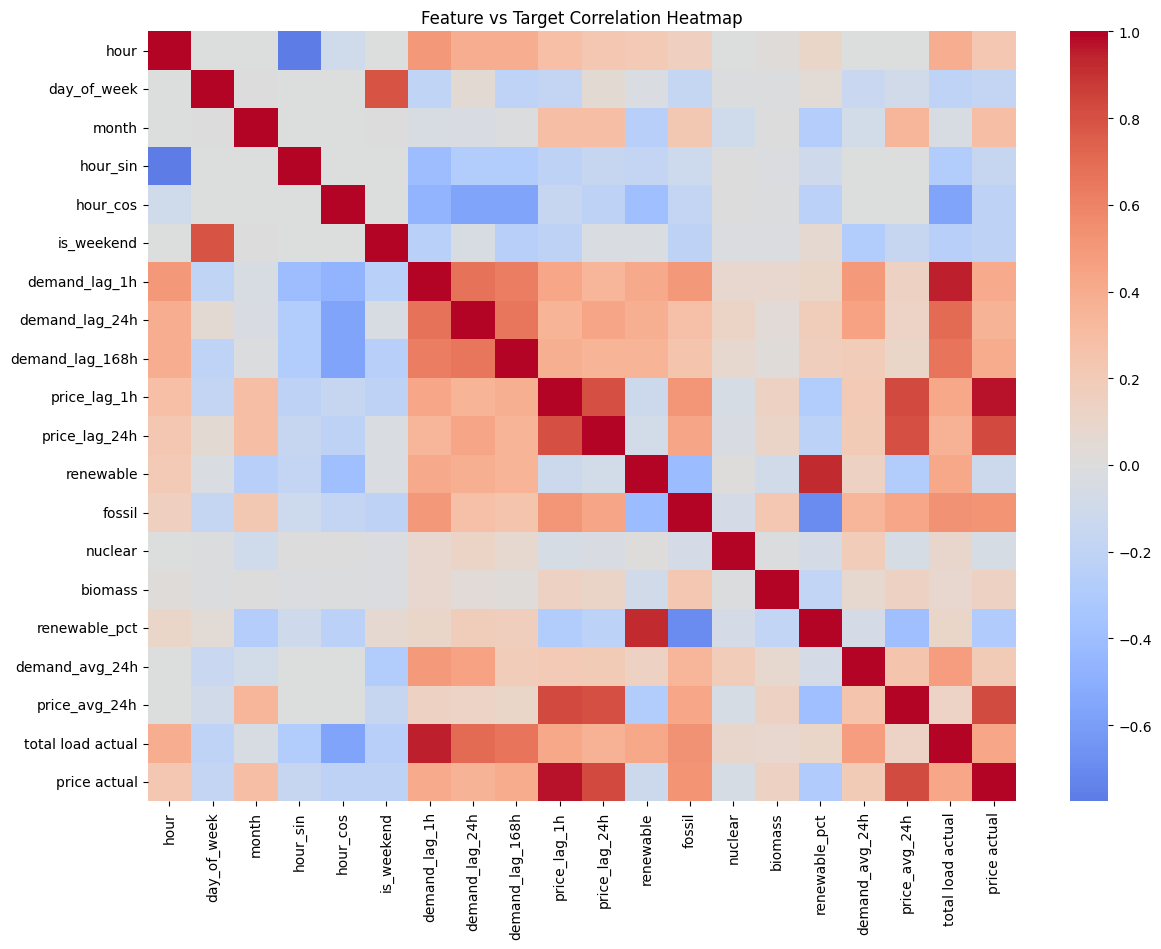

In [118]:


cols_to_check = feature_cols + target_cols

corr = df[cols_to_check].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr, annot=False, cmap='coolwarm', center=0)
plt.title("Feature vs Target Correlation Heatmap")
plt.show()

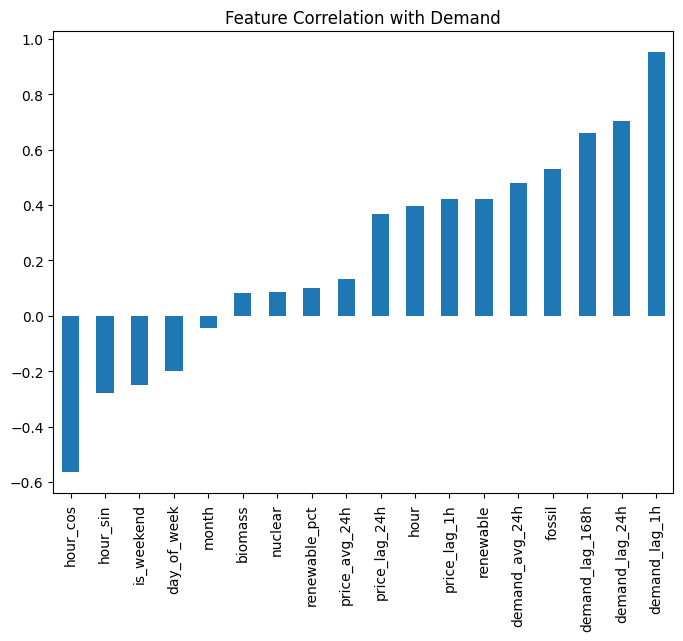

In [119]:
#for demand
demand_corr = df[feature_cols + ['total load actual']].corr()['total load actual'].sort_values()

plt.figure(figsize=(8,6))
demand_corr.drop('total load actual').plot(kind='bar')
plt.title("Feature Correlation with Demand")
plt.show()

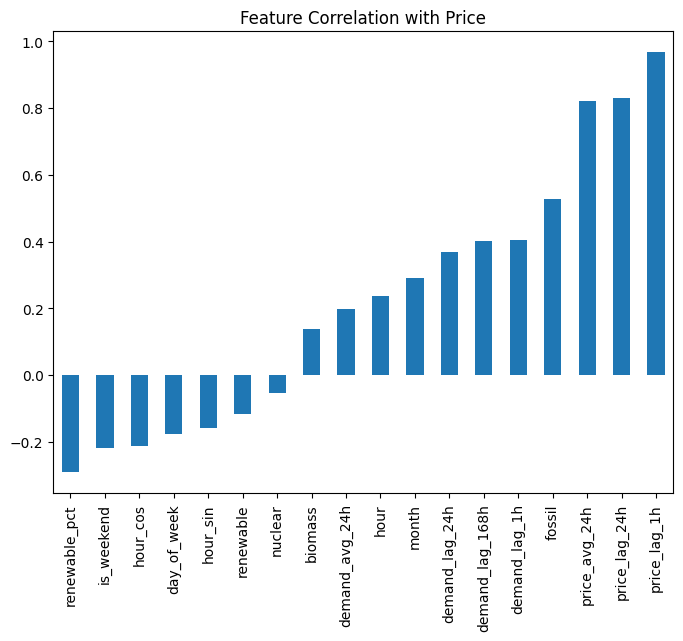

In [120]:
#for price
price_corr = df[feature_cols + ['price actual']].corr()['price actual'].sort_values()

plt.figure(figsize=(8,6))
price_corr.drop('price actual').plot(kind='bar')
plt.title("Feature Correlation with Price")
plt.show()

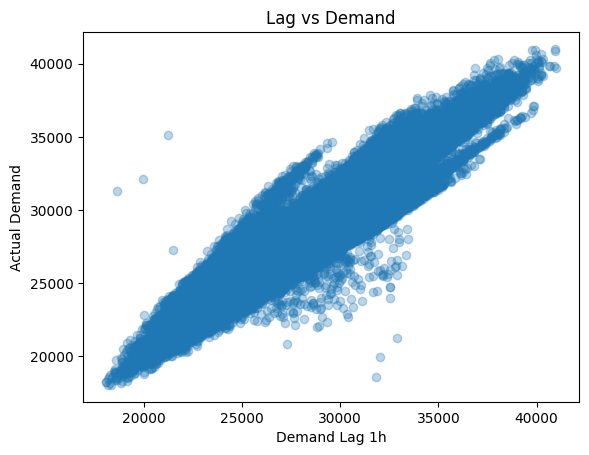

In [121]:
plt.scatter(df['demand_lag_1h'], df['total load actual'], alpha=0.3)
plt.xlabel("Demand Lag 1h")
plt.ylabel("Actual Demand")
plt.title("Lag vs Demand")
plt.show()